In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import LineCollection
import importlib
import scipy.linalg
sys.path.append('..')

# Now Python can see the 'src' folder!
import src.R2FMath as R2FMath
importlib.reload(R2FMath)

<module 'src.R2FMath' from 'c:\\python\\CeramicCap3\\analysis\\..\\src\\R2FMath.py'>

In [3]:
bd = r'U:\012 - CeramicCap\CAPDATA\2519J00896'
#fn ='VOLT_100nF-10nF_20260225_0848.dat'
#fn ='VOLT_1uF-100nF_20260225_1213.dat'
fn ='VOLT_10nF-1nF_20260224_1146.dat' 
data = np.loadtxt(os.path.join(bd,fn))
ave = 0.5*(data[0:-1:2,:]+data[1::2,:])

In [5]:
be =8*26
en = be+8

eta2 =  1000*(ave[be:en,4]+1j*ave[be:en,5])/(ave[be:en,2]+1j*ave[be:en,3])
eta3 =  1000*(ave[be:en,6]+1j*ave[be:en,7])/(ave[be:en,2]+1j*ave[be:en,3])
eta4 =  1000*(ave[be:en,8]+1j*ave[be:en,9])/(ave[be:en,2]+1j*ave[be:en,3])

elli2 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta2)
elli3 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta3)
elli4 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta4)

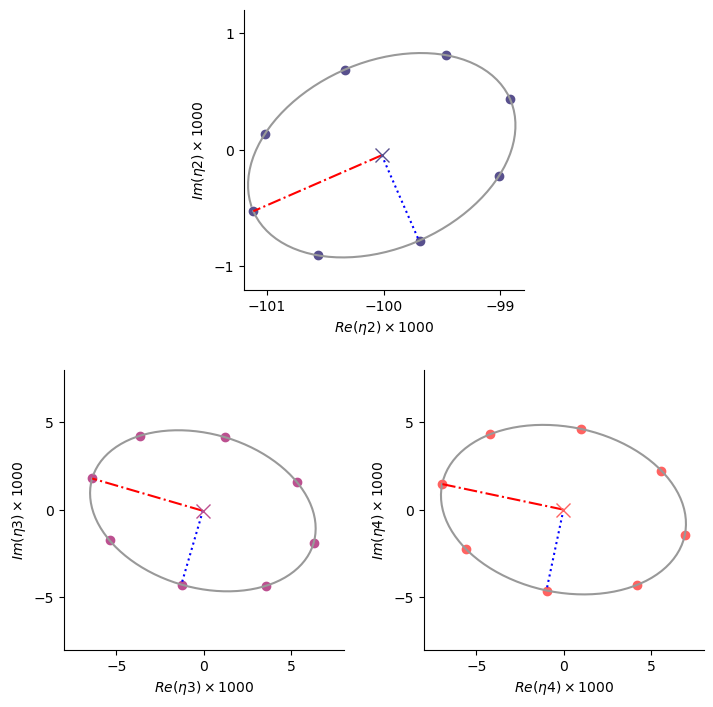

In [6]:
co1='#003f5c'
co2='#444e86'
co3='#955196'
co4='#dd5182'
co1='#58508d'
co2='#bc5090'
co3='#ff6361'
co4='#ffa600'
fig = plt.figure(figsize=(8, 8))
ax = []
w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap
center_x = 0.5 - (w / 2)
ax.append(fig.add_axes((center_x, 0.1 + h + dh, w, h)))
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))
ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))
ax[0].plot(np.real(eta2),np.imag(eta2),marker='o',c=co1,linestyle='None')
ax[1].plot(np.real(eta3),np.imag(eta3),marker='o',c=co2,linestyle='None')
ax[2].plot(np.real(eta4),np.imag(eta4),marker='o',c=co3,linestyle='None')
elli2.plot_elli(ax[0],ellipse_color='#999999')
elli3.plot_elli(ax[1],ellipse_color='#999999')
elli4.plot_elli(ax[2],ellipse_color='#999999')

ax[0].plot(np.real(elli2.eta_o),np.imag(elli2.eta_o),marker='x',ms=10,c=co1,linestyle='None')
ax[1].plot(np.real(elli3.eta_o),np.imag(elli3.eta_o),marker='x',ms=10,c=co2,linestyle='None')
ax[2].plot(np.real(elli4.eta_o),np.imag(elli4.eta_o),marker='x',ms=10,c=co3,linestyle='None')


ax[0].set_xlim(-101.2,-98.8)
ax[0].set_ylim(-1.2,1.2)
ax[1].set_xlim(-8,8)
ax[1].set_ylim(-8,8)

ax[2].set_xlim(-8,8)
ax[2].set_ylim(-8,8)

ax[0].set_xticks([-101,-100,-99])
ax[0].set_yticks([-1,0,1])
ax[1].set_yticks([-5,0,5])
ax[2].set_yticks([-5,0,5])

for n,axs in enumerate(ax):
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.set_xlabel(f'$Re(\eta{n+2})'+r'\times 1000$')
    axs.set_ylabel(f'$Im(\eta{n+2})'+r'\times 1000$')
    axs.ticklabel_format(useOffset=False)

fig.savefig('ellipses.pdf',bbox_inches='tight', 
               transparent=True,
               pad_inches=0)